In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/india_agriculture_seed_sales_data.csv')

In [6]:
# Monthly Seasonality 
seasonal = df.groupby('Month').agg(
    Avg_Sales=('Actual_Units_Sold', 'mean'),
    Avg_Revenue=('Total_Revenue', 'mean'),
    Avg_Profit=('Profit_Margin_%', 'mean'),
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temp=('Temperature_C', 'mean'),
    Avg_Days_Sell=('Days_to_Sell_Inventory', 'mean')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal['Month_Name'] = seasonal['Month'].apply(lambda x: month_names[x-1])

print('\nSeasonal Profile:')
print(seasonal[['Month_Name','Avg_Sales','Avg_Rainfall','Avg_Temp','Avg_Profit']].to_string(index=False))

print('\nPeak Sales Months:',
      list(seasonal.nlargest(3, 'Avg_Sales')['Month_Name']))
print('Lowest Profit Months:',
      list(seasonal.nsmallest(3, 'Avg_Profit')['Month_Name']))


Seasonal Profile:
Month_Name  Avg_Sales  Avg_Rainfall  Avg_Temp  Avg_Profit
       Jan 952.873529     74.830353 26.342706    6.118882
       Feb 949.175097     74.827432 26.582620    6.142678
       Mar 945.304885     75.252678 26.475044    6.114520
       Apr 949.938564     75.671655 26.466849    6.141387
       May 950.820377     74.311307 26.749470    6.098528
       Jun 947.012165     74.913990 26.593735    6.159465
       Jul 947.286219     74.949058 26.434335    6.178551
       Aug 953.358824     75.608941 26.511882    6.168218
       Sep 960.819842     74.645526 26.461229    6.145094
       Oct 948.750441     76.455621 26.677516    6.130818
       Nov 944.644769     74.493735 26.327676    6.143504
       Dec 945.789816     75.829011 26.562522    6.221237

Peak Sales Months: ['Sep', 'Aug', 'Jan']
Lowest Profit Months: ['May', 'Mar', 'Jan']


Rainfall Impact on Sales

In [9]:
rainfall_bins = pd.cut(df['Rainfall_mm'],
    bins=[-1, 0, 50, 150, 300, float('inf')],
    labels=['No Rain','Low (0-50)','Moderate (50-150)','High (150-300)','Very High (300+)'])
df['Rainfall_Category'] = rainfall_bins

rain_impact = df.groupby('Rainfall_Category', observed=True).agg(
    Avg_Units_Sold=('Actual_Units_Sold','mean'),
    Avg_Revenue=('Total_Revenue','mean'),
    Avg_Margin=('Profit_Margin_%','mean'),
    Count=('Actual_Units_Sold','count')
).round(2)
print("Rainfall Impact on Sales:")
print(rain_impact)

Rainfall Impact on Sales:
                   Avg_Units_Sold  Avg_Revenue  Avg_Margin  Count
Rainfall_Category                                                
No Rain                   1000.40    159052.25        6.24      5
Low (0-50)                 947.92    178104.07        6.14   6529
Moderate (50-150)          950.46    177586.86        6.15  13466


 Temperature Optimal Range

In [8]:
df['Temp_Band'] = pd.cut(df['Temperature_C'],
    bins=[0, 15, 20, 25, 30, 35, 50],
    labels=['<15°C','15-20°C','20-25°C','25-30°C','30-35°C','>35°C'])

temp_impact = df.groupby(['Vegetable_Type','Temp_Band'], observed=True)[
    'Actual_Units_Sold'].mean().unstack().round(1)
print("\nOptimal Temperature by Crop (Avg Units Sold):")
print(temp_impact)


Optimal Temperature by Crop (Avg Units Sold):
Temp_Band       15-20°C  20-25°C  25-30°C  30-35°C
Vegetable_Type                                    
Carrot            931.2    943.8    940.5    950.4
Cauliflower       950.3    963.7    951.3    941.6
Chili             945.7    949.5    943.1    962.7
Okra              948.6    939.7    958.2    953.9
Onion             964.4    950.9    943.4    962.7
Tomato            947.8    951.9    947.0    941.0


Weather Risk by Region

In [4]:
weather_risk = df.groupby('Region').agg(
    Rainfall_CV=('Rainfall_mm', lambda x: x.std()/x.mean()*100),
    Temp_StdDev=('Temperature_C','std'),
    Pest_Avg=('Pest_Infestation_Index','mean'),
    Revenue_Volatility=('Total_Revenue', lambda x: x.std()/x.mean()*100)
).round(2)
print("\nWeather Risk Score by Region:")
print(weather_risk.sort_values('Revenue_Volatility', ascending=False))


Weather Risk Score by Region:
         Rainfall_CV  Temp_StdDev  Pest_Avg  Revenue_Volatility
Region                                                         
West           57.37         4.91      0.08               37.70
North          57.34         4.94      0.08               37.61
Central        57.32         4.97      0.08               37.48
South          57.58         4.89      0.08               37.29
East           56.99         4.90      0.08               37.09


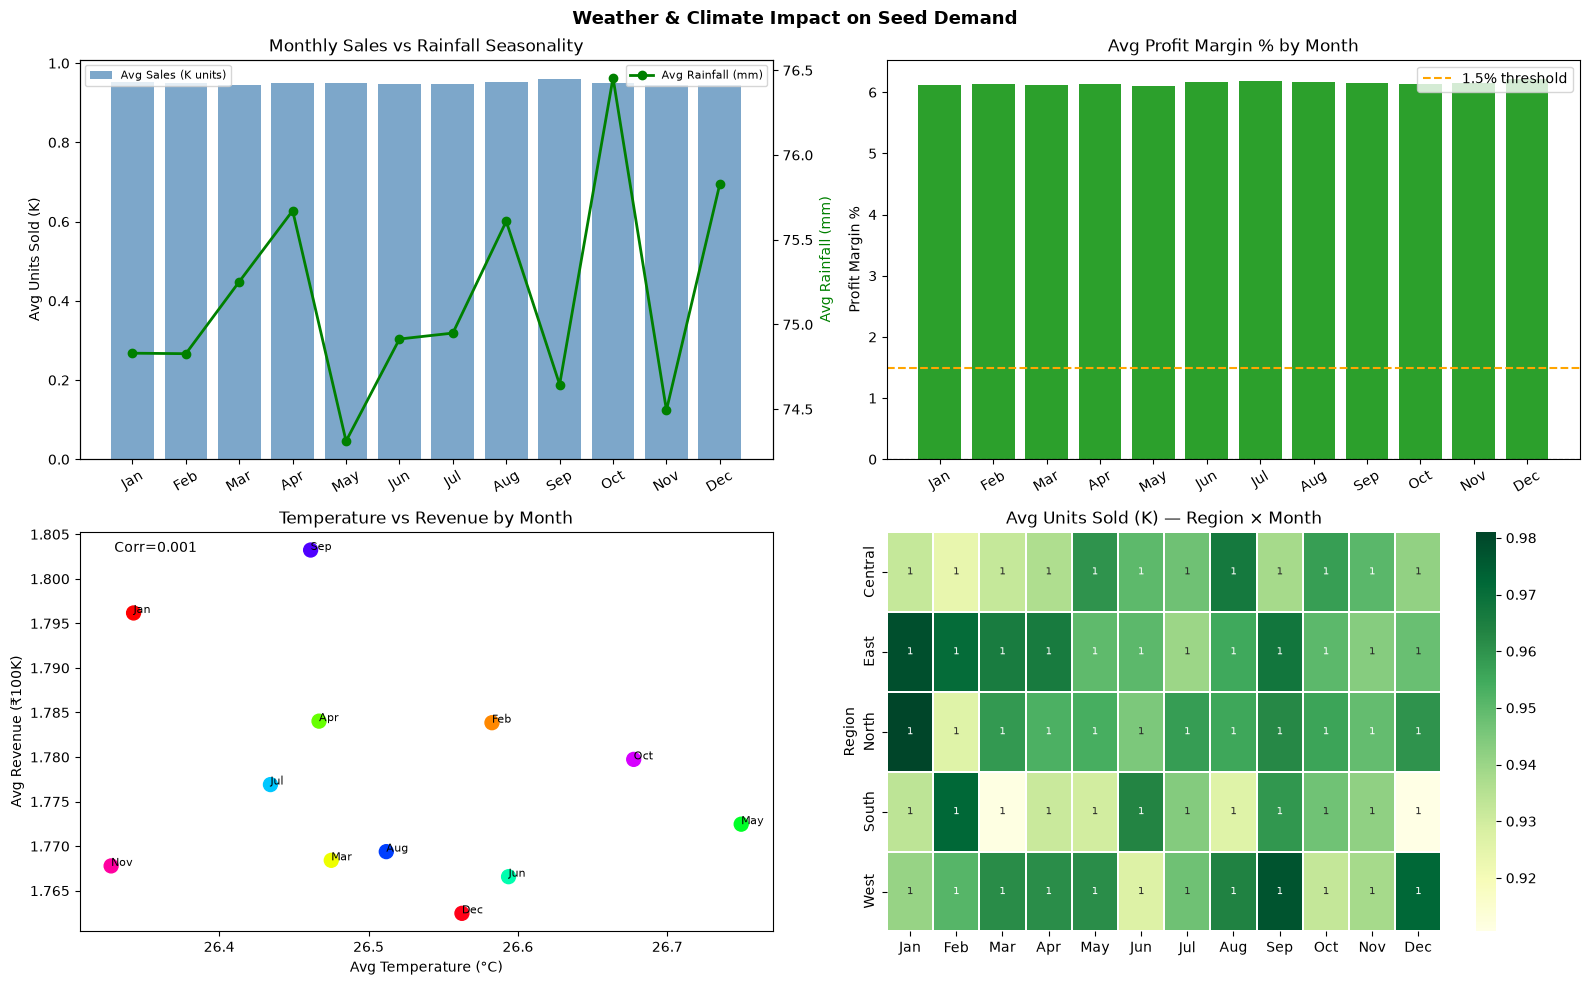

In [7]:
# Figures 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Monthly sales & rainfall overlay
ax_rain = axes[0, 0].twinx()
axes[0, 0].bar(seasonal['Month_Name'], seasonal['Avg_Sales'] / 1000,
               color='steelblue', alpha=0.7, label='Avg Sales (K units)')
ax_rain.plot(seasonal['Month_Name'], seasonal['Avg_Rainfall'],
             'g-o', lw=2, label='Avg Rainfall (mm)')
axes[0, 0].set_title('Monthly Sales vs Rainfall Seasonality')
axes[0, 0].set_ylabel('Avg Units Sold (K)')
ax_rain.set_ylabel('Avg Rainfall (mm)', color='green')
axes[0, 0].legend(loc='upper left', fontsize=8)
ax_rain.legend(loc='upper right', fontsize=8)
axes[0, 0].tick_params(axis='x', rotation=30)

# Panel 2: Profit margin by month
colors_bar = ['#d62728' if v < 0 else '#ff7f0e' if v < 5 else '#2ca02c'
              for v in seasonal['Avg_Profit']]
axes[0, 1].bar(seasonal['Month_Name'], seasonal['Avg_Profit'], color=colors_bar)
axes[0, 1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0, 1].axhline(1.5, color='orange', lw=1.5, linestyle='--', label='1.5% threshold')
axes[0, 1].set_title('Avg Profit Margin % by Month')
axes[0, 1].set_ylabel('Profit Margin %')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=30)

# Panel 3: Temperature vs Revenue (monthly)
axes[1, 0].scatter(seasonal['Avg_Temp'], seasonal['Avg_Revenue'] / 1e5,
                   s=100, c=range(12), cmap='hsv', zorder=3)
for _, row in seasonal.iterrows():
    axes[1, 0].annotate(row['Month_Name'],
                        (row['Avg_Temp'], row['Avg_Revenue'] / 1e5), fontsize=8)
axes[1, 0].set_xlabel('Avg Temperature (°C)')
axes[1, 0].set_ylabel('Avg Revenue (₹100K)')
axes[1, 0].set_title('Temperature vs Revenue by Month')
corr_temp = df['Temperature_C'].corr(df['Total_Revenue'])
axes[1, 0].text(0.05, 0.95, f'Corr={corr_temp:.3f}', transform=axes[1, 0].transAxes)

# Panel 4: Region x Month profit heatmap (seasonal pattern)
region_month = df.pivot_table(values='Actual_Units_Sold',
                               index='Region', columns='Month', aggfunc='mean')
region_month.columns = month_names
sns.heatmap(region_month / 1000, annot=True, fmt='.0f', cmap='YlGn',
            ax=axes[1, 1], linewidths=0.3, annot_kws={'size': 7})
axes[1, 1].set_title('Avg Units Sold (K) — Region × Month')

plt.suptitle('Weather & Climate Impact on Seed Demand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/weather_climate.png', bbox_inches='tight')
plt.show()